# Time Series Creator
    - Author Concetta D'Amato
    - Licence Creative Commons 4.0

In [1]:
import os
import numpy as np
import pandas as pd
import calendar
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from timeseries_writer import *
from netCDF4 import Dataset
import matplotlib.ticker as mtick
import gf
import time
import datetime
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
oms_project_path = os.path.dirname(os.getcwd())

## Create Date Time Index

To create the timeseries it is possible to use the method `pandas.date_range()`

The timeseries can be specified by defining the start date `start` and the end date `end`, or the start date `start` and the number of periods `periods`.

The frequency is defined by `freq`:
- `D` daily;
- `H` hourly;
- `T` minutes;

In [2]:
date_rng = pd.date_range(start='05/10/2018 00:00', end='07/01/2018 23:00' , freq='1H')
date_rng

DatetimeIndex(['2018-05-10 00:00:00', '2018-05-10 01:00:00',
               '2018-05-10 02:00:00', '2018-05-10 03:00:00',
               '2018-05-10 04:00:00', '2018-05-10 05:00:00',
               '2018-05-10 06:00:00', '2018-05-10 07:00:00',
               '2018-05-10 08:00:00', '2018-05-10 09:00:00',
               ...
               '2018-07-01 14:00:00', '2018-07-01 15:00:00',
               '2018-07-01 16:00:00', '2018-07-01 17:00:00',
               '2018-07-01 18:00:00', '2018-07-01 19:00:00',
               '2018-07-01 20:00:00', '2018-07-01 21:00:00',
               '2018-07-01 22:00:00', '2018-07-01 23:00:00'],
              dtype='datetime64[ns]', length=1272, freq='H')

## Create data

In [3]:
ID_basin = 1

In [4]:
d=len(date_rng)
dataframe = np.zeros(d)
#set the minimum value of time series m
m=6
#set the maximum value of time series M
M=6.5
for i in range(0,d):
    #create a time series with a costant value
    #dataframe[i] = 0.25
    
    #create a sinusoidal timeseries
    dataframe[i] = (m+M)/2 + ((m+M)/2-m)*np.sin(2*np.pi/(80*24)*i)

In [5]:
dfOut = pd.DataFrame(date_rng, columns=['date'])
dfOut['save'] = dataframe
dfOut.insert(loc=0, column='-', value=np.nan)
dfOut.head()

,-,date,save
0,NaN,2018-05-10 00:00:00,6.250000
1,NaN,2018-05-10 01:00:00,6.250818
2,NaN,2018-05-10 02:00:00,6.251636
3,NaN,2018-05-10 03:00:00,6.252454
4,NaN,2018-05-10 04:00:00,6.253272


/Users/concettadamato/opt/anaconda3/envs/geoframe_rossano/lib/python3.7/site-packages/ipykernel_launcher.py:3: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  This is separate from the ipykernel package so we can avoid doing imports until


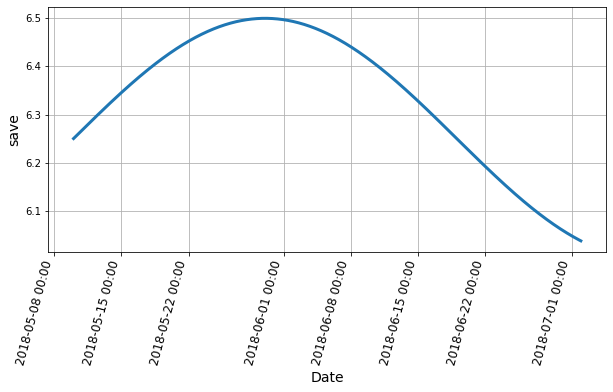

In [6]:
fig = plt.figure(figsize=(10,5))
ax = plt.subplot(111)
plt.plot(dfOut['date'],dfOut['save'], lineWidth =3)
plt.xlabel('Date',fontsize=14)
plt.ylabel('save', fontsize=14)   
plt.title('',fontsize=18)
fig.autofmt_xdate()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
xlabels = ax.get_xticklabels()
ax.xaxis.get_major_ticks()
for label in xlabels:
    label.set_rotation(75)
    label.set_fontsize(12)
plt.grid()
plt.show()


# Save to a .csv file

In [7]:
os.chdir(oms_project_path+"/data/SpikeII")
#os.listdir()

In [8]:
write_timeseries_csv(dfOut,'SpikeII_LAI_6_2909.csv',ID_basin)



***SUCCESS writing!  SpikeII_LAI_6_2909.csv
